=== PRICE PREDICTION TASK ===
🛒 eBay Auction Data Analysis Pipeline
Dropping unnamed index columns: ['Unnamed: 0']
✅ Successfully loaded data from _ebay.csv
📊 Dataset Overview:
Shape: (1000, 8)
Columns: ['item_category', 'item_condition', 'seller_rating', 'auction_duration', 'starting_price', 'number_of_bidders', 'buy_price', 'ship_price']

First few rows:
  item_category item_condition  seller_rating  auction_duration  \
0           Art            New           2.66                24   
1   Electronics    Refurbished           4.69                48   
2   Electronics            New           1.35                72   
3       Fashion    Refurbished           2.71                48   
4      Antiques            New           4.14                96   

   starting_price  number_of_bidders  buy_price  ship_price  
0          409.94                 46    1352.80     27.0560  
1          907.60                 48    3085.84     61.7168  
2          988.20                 77    4792.77     

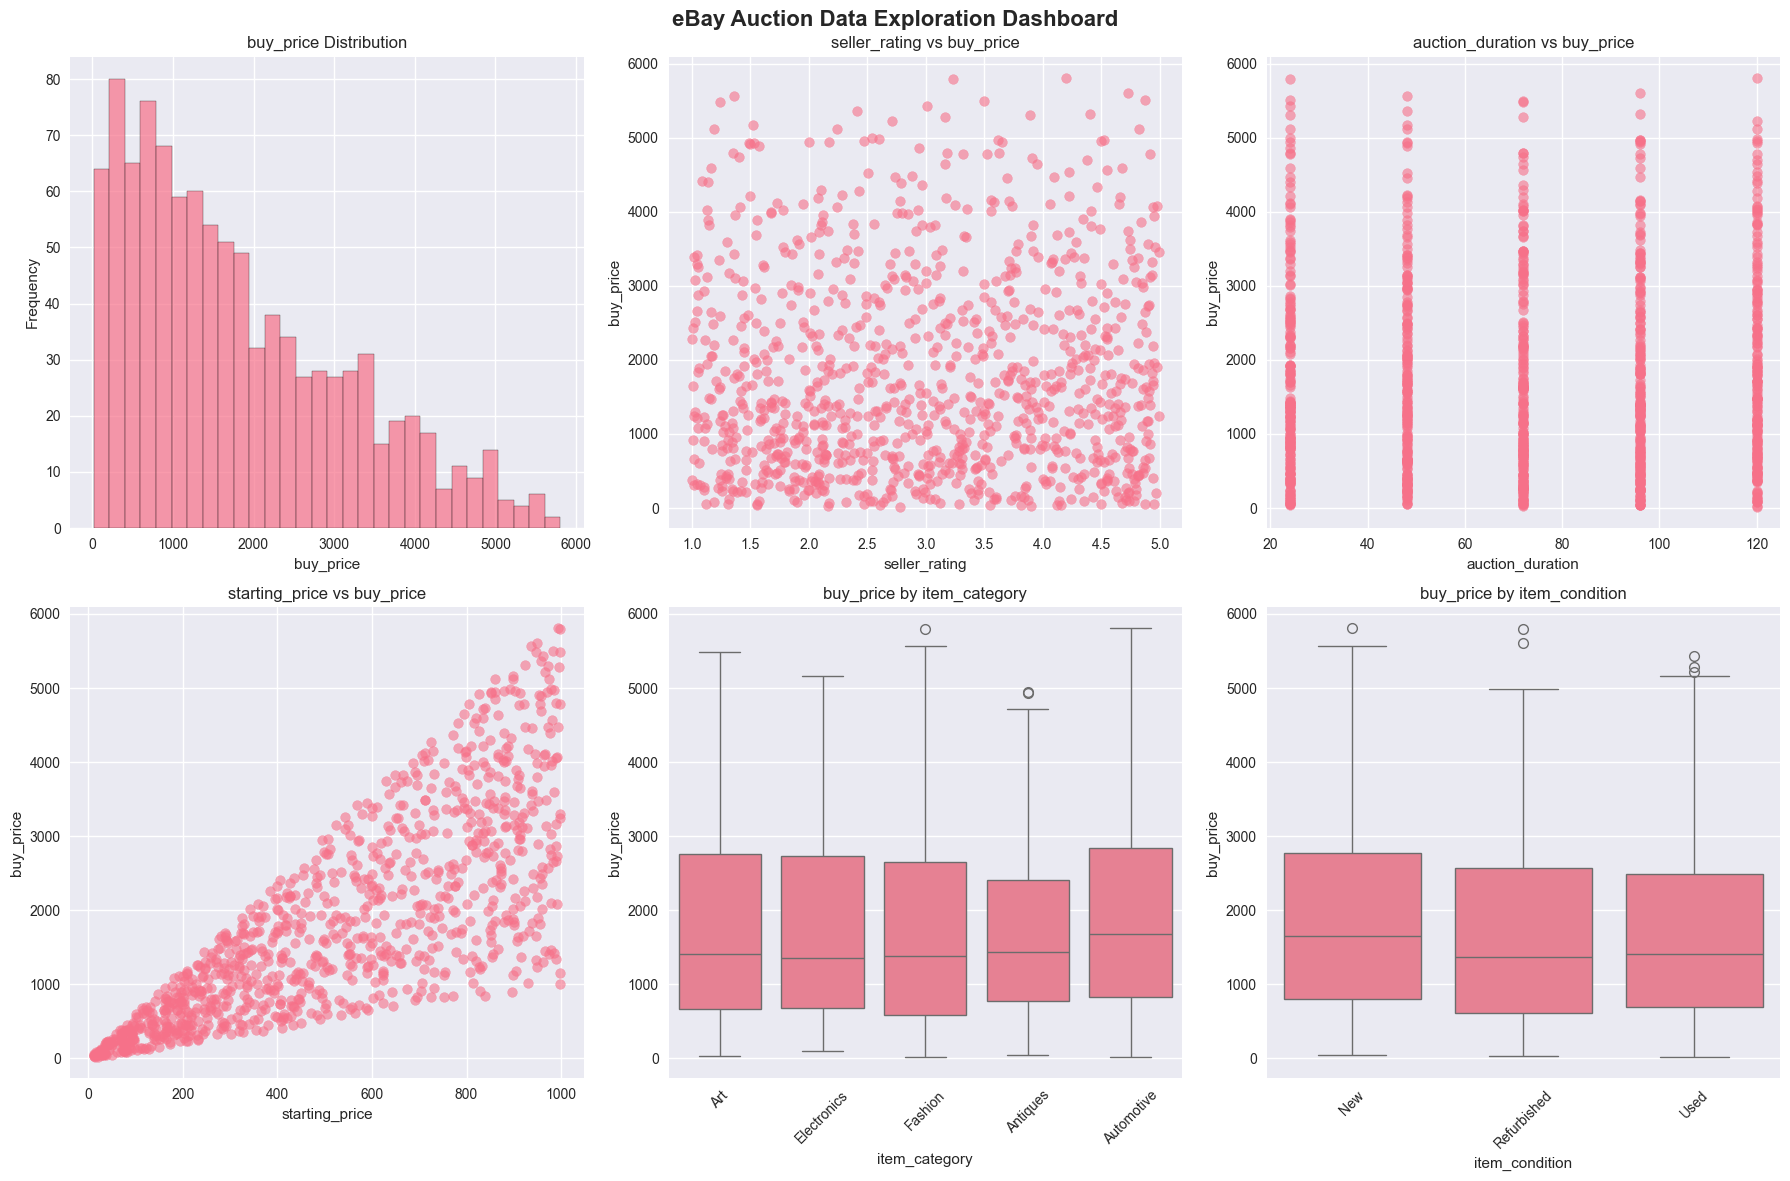


📈 Correlation Analysis
-------------------------
Correlations with target variable:
ship_price          1.000000
starting_price      0.790706
seller_rating       0.030992
auction_duration    0.014513
Name: buy_price, dtype: float64


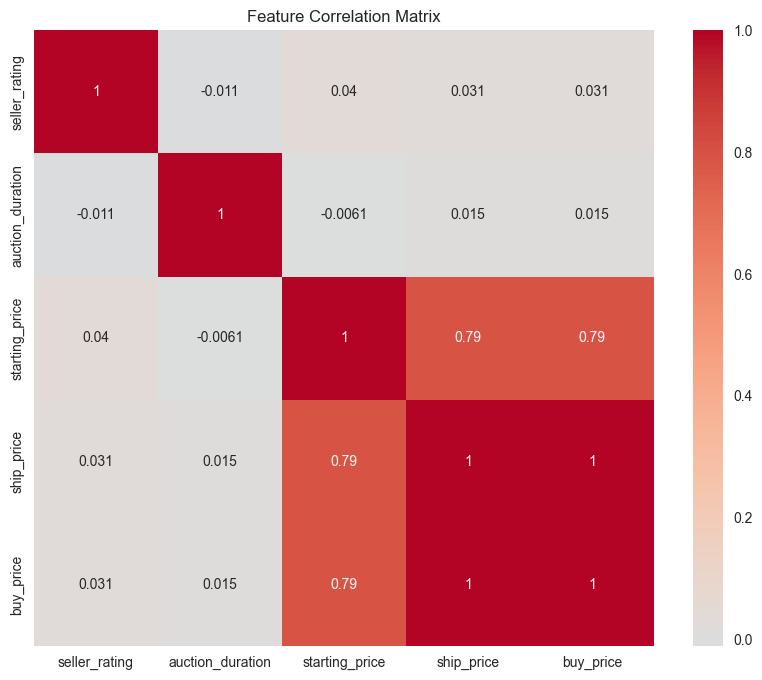


🚨 Data Leakage Risk Assessment
--------------------------------
  item_category: NO RISK - Available before auction
  item_condition: NO RISK - Available before auction
  seller_rating: NO RISK - Available before auction
  auction_duration: NO RISK - Set before auction starts
  starting_price: NO RISK - Set before auction starts
  number_of_bidders: MEDIUM RISK - Changes during auction, timing matters
  ship_price: LOW RISK - Usually known during auction

✅ Selected 6 safe features (excluding 1 identifiers):
Excluded identifiers: ['number_of_bidders']
Safe features: ['item_category', 'item_condition', 'seller_rating', 'auction_duration', 'starting_price', 'ship_price']

🤖 Training and Evaluating Models
-----------------------------------
Task type: regression
Using 1000 samples after cleaning

Training Linear Regression...
RMSE: 0.000
R² Score: 1.000

Training XGBoost...
RMSE: 29.321
R² Score: 1.000

🎯 Feature Importance Analysis
------------------------------
Top feature importances:

In [9]:
# eBay Auction Data Analysis Pipeline - Fixed Version
# Modular functions for reusable analysis across eBay datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_and_inspect_data(filepath):
    """
    Load data and perform initial inspection
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: Loaded dataframe
        dict: Basic info about the dataset
    """
    df = pd.read_csv(filepath)
    
    # Drop unnamed index columns (columns with no name or names like 'Unnamed: 0')
    unnamed_cols = [col for col in df.columns if 'Unnamed:' in str(col) or col == '']
    if unnamed_cols:
        print(f"Dropping unnamed index columns: {unnamed_cols}")
        df = df.drop(columns=unnamed_cols)
    
    print(f"✅ Successfully loaded data from {filepath}")
    
    info = {
        'shape': df.shape,
        'columns': list(df.columns),
        'dtypes': df.dtypes.to_dict(),
        'memory_usage': df.memory_usage(deep=True).sum()
    }
    
    print("📊 Dataset Overview:")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print("\nFirst few rows:")
    print(df.head())
    
    return df, info

def auto_detect_column_types(df):
    """
    Automatically detect numerical, categorical, and identifier columns for eBay data
    
    Args:
        df (pd.DataFrame): Input dataframe
        
    Returns:
        dict: Dictionary with column types
    """
    print(f"\n🔍 Auto-detecting Column Types")
    print("-" * 30)
    
    numerical_cols = []
    categorical_cols = []
    identifier_cols = []
    
    for col in df.columns:
        # Skip obvious identifiers - normalize spaces and case
        col_normalized = col.lower().replace(' ', '').replace('_', '')
        if any(keyword in col_normalized for keyword in ['id', 'itemid', 'sellerid', 'userid']):
            identifier_cols.append(col)
        # Numerical columns
        elif df[col].dtype in ['int64', 'float64']:
            numerical_cols.append(col)
        # Categorical columns (strings with reasonable number of unique values)
        elif df[col].dtype == 'object':
            unique_count = df[col].nunique()
            if unique_count <= 20:  # Reasonable threshold for categories
                categorical_cols.append(col)
            else:
                identifier_cols.append(col)  # Too many unique values, likely an identifier
    
    column_types = {
        'numerical': numerical_cols,
        'categorical': categorical_cols,
        'identifiers': identifier_cols
    }
    
    print("Detected column types:")
    print(f"Numerical: {numerical_cols}")
    print(f"Categorical: {categorical_cols}")
    print(f"Identifiers: {identifier_cols}")
    
    return column_types

def assess_data_quality(df, numerical_cols=None, categorical_cols=None):
    """
    Assess data quality issues and anomalies for eBay auction data
    
    Args:
        df (pd.DataFrame): Input dataframe
        numerical_cols (list): List of numerical column names
        categorical_cols (list): List of categorical column names
        
    Returns:
        dict: Data quality assessment results
    """
    print(f"\n📋 Data Quality Assessment")
    print("-" * 30)
    
    # Basic checks
    duplicates = df.duplicated().sum()
    missing_values = df.isnull().sum()
    
    print(f"Duplicate rows: {duplicates}")
    if missing_values.sum() > 0:
        print(f"Missing values per column:")
        print(missing_values[missing_values > 0])
    else:
        print("No missing values found ✅")
    
    quality_issues = {
        'duplicates': duplicates,
        'missing_values': missing_values.to_dict(),
        'anomalies': {}
    }
    
    # Domain-specific anomaly checks for eBay auction data
    if 'seller_rating' in df.columns:
        rating_high = (df['seller_rating'] > 5.0).sum()
        rating_low = (df['seller_rating'] < 0.0).sum()
        quality_issues['anomalies']['seller_rating_out_of_range'] = rating_high + rating_low
        if rating_high > 0:
            print(f"Seller rating > 5.0: {rating_high} records")
        if rating_low > 0:
            print(f"Seller rating < 0.0: {rating_low} records")
    
    if 'starting_price' in df.columns:
        negative_starting_price = (df['starting_price'] < 0).sum()
        quality_issues['anomalies']['negative_starting_price'] = negative_starting_price
        if negative_starting_price > 0:
            print(f"Negative starting price: {negative_starting_price} records")
    
    if 'buy_price' in df.columns and 'starting_price' in df.columns:
        buy_lower_than_start = (df['buy_price'] < df['starting_price']).sum()
        quality_issues['anomalies']['buy_price_lower_than_starting'] = buy_lower_than_start
        if buy_lower_than_start > 0:
            print(f"Buy price lower than starting price: {buy_lower_than_start} records")
    
    if 'auction_duration' in df.columns:
        unusual_duration = ((df['auction_duration'] < 1) | (df['auction_duration'] > 168)).sum()  # 1 hour to 1 week
        quality_issues['anomalies']['unusual_auction_duration'] = unusual_duration
        if unusual_duration > 0:
            print(f"Unusual auction duration (<1 or >168 hours): {unusual_duration} records")
    
    if 'number_of_bidders' in df.columns:
        negative_bidders = (df['number_of_bidders'] < 0).sum()
        quality_issues['anomalies']['negative_bidders'] = negative_bidders
        if negative_bidders > 0:
            print(f"Negative number of bidders: {negative_bidders} records")
    
    return quality_issues

def analyze_target_distribution(df, target_col):
    """
    Analyze the distribution of the target variable
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        
    Returns:
        dict: Target distribution statistics
    """
    print(f"\n🎯 Target Variable Analysis: {target_col}")
    print("-" * 35)
    
    if df[target_col].dtype in ['int64', 'float64']:
        # Numerical target (regression)
        stats = {
            'mean': df[target_col].mean(),
            'median': df[target_col].median(),
            'std': df[target_col].std(),
            'min': df[target_col].min(),
            'max': df[target_col].max()
        }
        print(f"Distribution statistics:")
        for key, value in stats.items():
            print(f"  {key}: {value:.2f}")
        
        return {'type': 'numerical', 'stats': stats}
    else:
        # Categorical target (classification)
        target_counts = df[target_col].value_counts()
        print(f"Distribution:")
        print(target_counts)
        
        return {'type': 'categorical', 'counts': target_counts.to_dict()}

def create_exploratory_visualizations(df, target_col, numerical_cols, categorical_cols):
    """
    Create comprehensive exploratory visualizations for eBay data
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        numerical_cols (list): List of numerical columns
        categorical_cols (list): List of categorical columns
    """
    print(f"\n🔍 Creating Exploratory Visualizations")
    print("-" * 40)
    
    # Calculate subplot dimensions
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('eBay Auction Data Exploration Dashboard', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    plot_idx = 0
    
    # Target variable distribution
    if plot_idx < len(axes):
        if df[target_col].dtype in ['int64', 'float64']:
            # Histogram for numerical target
            axes[plot_idx].hist(df[target_col], bins=30, alpha=0.7, edgecolor='black')
            axes[plot_idx].set_title(f'{target_col} Distribution')
            axes[plot_idx].set_xlabel(target_col)
            axes[plot_idx].set_ylabel('Frequency')
        else:
            # Bar plot for categorical target
            df[target_col].value_counts().plot(kind='bar', ax=axes[plot_idx])
            axes[plot_idx].set_title(f'{target_col} Distribution')
        plot_idx += 1
    
    # Numerical features analysis
    for col in numerical_cols[:3]:  # Limit to first 3 numerical columns
        if plot_idx < len(axes) and col in df.columns and col != target_col:
            if df[target_col].dtype in ['int64', 'float64']:
                # Scatter plot for numerical target
                axes[plot_idx].scatter(df[col], df[target_col], alpha=0.6)
                axes[plot_idx].set_xlabel(col)
                axes[plot_idx].set_ylabel(target_col)
                axes[plot_idx].set_title(f'{col} vs {target_col}')
            else:
                # Box plot for categorical target
                sns.boxplot(data=df, x=target_col, y=col, ax=axes[plot_idx])
                axes[plot_idx].set_title(f'{col} by {target_col}')
                axes[plot_idx].tick_params(axis='x', rotation=45)
            plot_idx += 1
    
    # Categorical features
    for col in categorical_cols[:2]:  # Limit to first 2 categorical columns
        if plot_idx < len(axes) and col in df.columns and col != target_col:
            unique_count = df[col].nunique()
            if unique_count <= 10:  # Only plot if reasonable number of categories
                if df[target_col].dtype in ['int64', 'float64']:
                    # Box plot for numerical target
                    sns.boxplot(data=df, x=col, y=target_col, ax=axes[plot_idx])
                    axes[plot_idx].set_title(f'{target_col} by {col}')
                    axes[plot_idx].tick_params(axis='x', rotation=45)
                else:
                    # Cross-tabulation for categorical target
                    pd.crosstab(df[col], df[target_col]).plot(kind='bar', ax=axes[plot_idx])
                    axes[plot_idx].set_title(f'{col} vs {target_col}')
                    axes[plot_idx].tick_params(axis='x', rotation=45)
                plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_feature_correlations(df, numerical_cols, target_col):
    """
    Analyze correlations between features and target - FIXED VERSION
    
    Args:
        df (pd.DataFrame): Input dataframe
        numerical_cols (list): List of numerical columns
        target_col (str): Name of target column
        
    Returns:
        pd.Series: Correlations with target variable
    """
    print(f"\n📈 Correlation Analysis")
    print("-" * 25)
    
    # Create a copy for correlation analysis
    df_corr = df.copy()
    
    # Encode target if categorical
    if df[target_col].dtype == 'object':
        le = LabelEncoder()
        df_corr[f'{target_col}_encoded'] = le.fit_transform(df[target_col])
        target_encoded = f'{target_col}_encoded'
    else:
        target_encoded = target_col
    
    # FIXED: Remove target column from numerical_cols to avoid duplication
    correlation_cols = [col for col in numerical_cols if col in df.columns and col != target_col]
    
    # Add the encoded target
    correlation_cols.append(target_encoded)
    
    if len(correlation_cols) <= 1:
        print("Insufficient numerical features for correlation analysis")
        return pd.Series(dtype=float)
    
    # Calculate correlations
    corr_matrix = df_corr[correlation_cols].corr()
    
    # Get correlations with target
    corr_with_target = corr_matrix[target_encoded].drop(target_encoded)
    
    # Sort correlations
    if len(corr_with_target) > 0:
        corr_with_target = corr_with_target.sort_values(ascending=False)
        
        print("Correlations with target variable:")
        print(corr_with_target)
        
        # Visualization
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Matrix')
        plt.show()
    else:
        print("No numerical features available for correlation analysis")
    
    return corr_with_target

def assess_data_leakage_risk(df, target_col):
    """
    Assess potential data leakage risks for eBay auction data
    
    Args:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target column
        
    Returns:
        dict: Leakage risk assessment
    """
    print(f"\n🚨 Data Leakage Risk Assessment")
    print("-" * 32)
    
    # Define leakage risk rules for eBay auction data
    leakage_rules = {
        'buy_price': 'HIGH RISK - Final sale price, known only after auction ends',
        'ship_price': 'LOW RISK - Usually known during auction',
        'starting_price': 'NO RISK - Set before auction starts',
        'seller_rating': 'NO RISK - Available before auction',
        'auction_duration': 'NO RISK - Set before auction starts',
        'item_category': 'NO RISK - Available before auction',
        'item_condition': 'NO RISK - Available before auction',
        'number_of_bidders': 'MEDIUM RISK - Changes during auction, timing matters',
        'final_bidders': 'HIGH RISK - Only known after auction ends',
        'winning_bid': 'HIGH RISK - Only known after auction ends',
        'sold': 'HIGH RISK - Outcome of auction'
    }
    
    assessment = {}
    for col in df.columns:
        if col != target_col:
            risk_level = leakage_rules.get(col, 'UNKNOWN RISK - Manual review needed')
            assessment[col] = risk_level
            print(f"  {col}: {risk_level}")
    
    # Specific checks for eBay auction data
    if 'buy_price' in df.columns and 'starting_price' in df.columns:
        # Check if buy_price is always higher than starting_price (expected behavior)
        price_anomalies = (df['buy_price'] < df['starting_price']).sum()
        if price_anomalies > 0:
            print(f"\n⚠️ WARNING: {price_anomalies} records where buy_price < starting_price")
            assessment['price_anomalies_detected'] = True
        else:
            assessment['price_anomalies_detected'] = False
    
    return assessment

def select_safe_features(df, leakage_assessment, column_types):
    """
    Select features that are safe to use (low leakage risk and not identifiers)
    
    Args:
        df (pd.DataFrame): Input dataframe
        leakage_assessment (dict): Output from assess_data_leakage_risk
        column_types (dict): Output from auto_detect_column_types
        
    Returns:
        list: List of safe feature names
    """
    safe_features = []
    
    # Get identifier columns to exclude
    identifier_cols = column_types.get('identifiers', [])
    
    for feature, risk in leakage_assessment.items():
        if feature not in ['price_anomalies_detected']:
            if 'NO RISK' in risk or 'LOW RISK' in risk:
                if feature in df.columns and feature not in identifier_cols:
                    safe_features.append(feature)
    
    print(f"\n✅ Selected {len(safe_features)} safe features (excluding {len(identifier_cols)} identifiers):")
    print(f"Excluded identifiers: {identifier_cols}")
    print(f"Safe features: {safe_features}")
    
    return safe_features

def make_regression_pipeline():
    """
    Create a regression pipeline with preprocessing
    
    Returns:
        Pipeline: Scikit-learn pipeline for regression
    """
    # Numerical preprocessing
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical preprocessing
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    
    # Combined preprocessor
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, lambda X: X.select_dtypes(include=[np.number]).columns.tolist()),
        ('cat', cat_pipeline, lambda X: X.select_dtypes(include=['object']).columns.tolist())
    ])
    
    # Complete pipeline with XGBoost Regressor
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', xgb.XGBRegressor(
            n_estimators=100, 
            random_state=42,
            verbosity=0
        ))
    ])
    
    return pipeline

def make_classification_pipeline():
    """
    Create a classification pipeline with preprocessing
    
    Returns:
        Pipeline: Scikit-learn pipeline for classification
    """
    # Numerical preprocessing
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical preprocessing
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    
    # Combined preprocessor
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, lambda X: X.select_dtypes(include=[np.number]).columns.tolist()),
        ('cat', cat_pipeline, lambda X: X.select_dtypes(include=['object']).columns.tolist())
    ])
    
    # Complete pipeline with XGBoost Classifier
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            n_estimators=100, 
            random_state=42, 
            eval_metric='logloss',
            verbosity=0
        ))
    ])
    
    return pipeline

def tune_hyperparameters(X_train, y_train, task_type='regression'):
    """
    Perform hyperparameter tuning using GridSearchCV with 5-fold cross-validation
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (array-like): Training target
        task_type (str): 'regression' or 'classification'
        
    Returns:
        tuple: (best_pipeline, best_params, cv_results)
    """
    print(f"\n🔧 Hyperparameter Tuning for XGBoost ({task_type})")
    print("-" * 45)
    
    # Create base pipeline
    if task_type == 'regression':
        base_pipeline = make_regression_pipeline()
        scoring = 'neg_mean_squared_error'
        param_prefix = 'regressor'
    else:
        base_pipeline = make_classification_pipeline()
        scoring = 'roc_auc'
        param_prefix = 'classifier'
    
    # Define parameter grid
    param_grid = {
        f'{param_prefix}__n_estimators': [50, 100, 200],
        f'{param_prefix}__max_depth': [3, 6, 9],
        f'{param_prefix}__learning_rate': [0.01, 0.1, 0.2],
        f'{param_prefix}__subsample': [0.8, 1.0],
        f'{param_prefix}__colsample_bytree': [0.8, 1.0]
    }
    
    # Perform grid search with 5-fold cross-validation
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )
    
    print("Starting hyperparameter tuning...")
    combinations = len(param_grid[f'{param_prefix}__n_estimators']) * \
                  len(param_grid[f'{param_prefix}__max_depth']) * \
                  len(param_grid[f'{param_prefix}__learning_rate']) * \
                  len(param_grid[f'{param_prefix}__subsample']) * \
                  len(param_grid[f'{param_prefix}__colsample_bytree'])
    print(f"Testing {combinations} parameter combinations")
    
    grid_search.fit(X_train, y_train)
    
    print(f"✅ Hyperparameter tuning complete!")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.cv_results_

def train_and_evaluate_models(df, feature_cols, target_col, tune_hyperparams=False):
    """
    Train and evaluate models (regression or classification based on target type)
    
    Args:
        df (pd.DataFrame): Input dataframe
        feature_cols (list): List of feature column names
        target_col (str): Name of target column
        tune_hyperparams (bool): Whether to perform hyperparameter tuning
        
    Returns:
        dict: Model results and metrics
    """
    print(f"\n🤖 Training and Evaluating Models")
    print("-" * 35)
    
    # Prepare data
    X = df[feature_cols].copy()
    
    # Clean target variable - remove any NaN values
    target_data = df[target_col].dropna()
    valid_indices = target_data.index
    X = X.loc[valid_indices]
    
    # Determine if regression or classification
    is_regression = target_data.dtype in ['int64', 'float64']
    task_type = 'regression' if is_regression else 'classification'
    
    print(f"Task type: {task_type}")
    print(f"Using {len(X)} samples after cleaning")
    
    if is_regression:
        y = target_data.values
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        
        # Define models
        models = {
            'Linear Regression': Pipeline([
                ('preprocessor', make_regression_pipeline().named_steps['preprocessor']),
                ('regressor', LinearRegression())
            ])
        }
        
        # Add XGBoost model (tuned or default)
        if tune_hyperparams:
            print("Training XGBoost with hyperparameter tuning...")
            tuned_xgb, best_params, cv_results = tune_hyperparameters(X_train, y_train, 'regression')
            models['XGBoost (Tuned)'] = tuned_xgb
        else:
            models['XGBoost'] = make_regression_pipeline()
        
        results = {}
        
        for name, pipeline in models.items():
            print(f"\nTraining {name}...")
            
            # Skip fitting for tuned XGBoost as it's already fitted
            if name == 'XGBoost (Tuned)':
                pass
            else:
                pipeline.fit(X_train, y_train)
            
            # Predictions
            y_pred = pipeline.predict(X_test)
            
            # Metrics
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)
            
            results[name] = {
                'pipeline': pipeline,
                'mse': mse,
                'rmse': rmse,
                'r2_score': r2,
                'predictions': y_pred
            }
            
            print(f"RMSE: {rmse:.3f}")
            print(f"R² Score: {r2:.3f}")
    
    else:
        # Classification
        # Encode target if needed
        le = LabelEncoder()
        y = le.fit_transform(target_data)
        target_classes = [str(cls) for cls in le.classes_.tolist()]
        
        print(f"Target classes: {target_classes}")
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # Define models
        models = {
            'Logistic Regression': Pipeline([
                ('preprocessor', make_classification_pipeline().named_steps['preprocessor']),
                ('classifier', LogisticRegression(random_state=42, max_iter=1000))
            ])
        }
        
        # Add XGBoost model (tuned or default)
        if tune_hyperparams:
            print("Training XGBoost with hyperparameter tuning...")
            tuned_xgb, best_params, cv_results = tune_hyperparameters(X_train, y_train, 'classification')
            models['XGBoost (Tuned)'] = tuned_xgb
        else:
            models['XGBoost'] = make_classification_pipeline()
        
        results = {}
        
        for name, pipeline in models.items():
            print(f"\nTraining {name}...")
            
            # Skip fitting for tuned XGBoost as it's already fitted
            if name == 'XGBoost (Tuned)':
                pass
            else:
                pipeline.fit(X_train, y_train)
            
            # Predictions
            y_pred = pipeline.predict(X_test)
            y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if len(np.unique(y)) == 2 else None
            
            # Metrics
            accuracy = accuracy_score(y_test, y_pred)
            auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            results[name] = {
                'pipeline': pipeline,
                'accuracy': accuracy,
                'auc_score': auc_score,
                'predictions': y_pred,
                'probabilities': y_pred_proba
            }
            
            print(f"Accuracy: {accuracy:.3f}")
            if auc_score:
                print(f"AUC Score: {auc_score:.3f}")
            print("Classification Report:")
            print(classification_report(y_test, y_pred, target_names=target_classes))
    
    return results

def extract_feature_importance(model_results, feature_cols):
    """
    Extract and display feature importance from trained models
    
    Args:
        model_results (dict): Results from train_and_evaluate_models
        feature_cols (list): List of feature column names
        
    Returns:
        pd.DataFrame: Feature importance scores
    """
    print(f"\n🎯 Feature Importance Analysis")
    print("-" * 30)
    
    # Get XGBoost model (tuned or default)
    target_pipeline = None
    for name, results in model_results.items():
        if 'XGBoost' in name:
            target_pipeline = results['pipeline']
            break
    
    if target_pipeline is None:
        print("No XGBoost model found for feature importance extraction")
        return None
    
    # Extract feature names after preprocessing
    preprocessor = target_pipeline.named_steps['preprocessor']
    
    # Get the model (regressor or classifier)
    if 'regressor' in target_pipeline.named_steps:
        model = target_pipeline.named_steps['regressor']
    else:
        model = target_pipeline.named_steps['classifier']
    
    # Get feature names (this is tricky with ColumnTransformer)
    try:
        feature_names = preprocessor.get_feature_names_out()
    except:
        # Fallback: use original feature names (not ideal but works)
        feature_names = feature_cols
    
    # Get importance scores
    if hasattr(model, 'feature_importances_'):
        importance_scores = model.feature_importances_
        
        # Create DataFrame
        n_features = min(len(feature_names), len(importance_scores))
        importance_df = pd.DataFrame({
            'feature': feature_names[:n_features],
            'importance': importance_scores[:n_features]
        }).sort_values('importance', ascending=False)
        
        print("Top feature importances:")
        print(importance_df.head(10))
        
        return importance_df
    
    return None

def calculate_pipeline_readiness_score(quality_issues, model_results, leakage_assessment):
    """
    Calculate an overall pipeline readiness score
    
    Args:
        quality_issues (dict): Data quality assessment results
        model_results (dict): Model evaluation results
        leakage_assessment (dict): Leakage risk assessment
        
    Returns:
        dict: Readiness scores and overall assessment
    """
    print(f"\n💡 Pipeline Readiness Assessment")
    print("-" * 32)
    
    # Data quality score (0-100)
    quality_score = 100
    if quality_issues['duplicates'] > 0:
        quality_score -= 10
    
    missing_penalty = sum(1 for count in quality_issues['missing_values'].values() if count > 0)
    quality_score -= min(missing_penalty * 5, 30)
    
    anomaly_penalty = sum(quality_issues['anomalies'].values())
    quality_score -= min(anomaly_penalty, 30)
    
    quality_score = max(0, quality_score)
    
    # Model performance score (0-100)
    if model_results:
        # Check if regression or classification
        first_result = next(iter(model_results.values()))
        if 'r2_score' in first_result:
            # Regression - use R² score
            best_r2 = max([r.get('r2_score', 0) for r in model_results.values()])
            performance_score = max(0, best_r2) * 100  # R² can be negative
        else:
            # Classification - use AUC or accuracy
            best_auc = max([r.get('auc_score', 0) or 0 for r in model_results.values()])
            best_accuracy = max([r.get('accuracy', 0) for r in model_results.values()])
            performance_score = max(best_auc, best_accuracy) * 100
    else:
        performance_score = 0
    
    # Leakage risk score (0-100)
    high_risk_count = sum(1 for risk in leakage_assessment.values() 
                         if isinstance(risk, str) and 'HIGH RISK' in risk)
    price_anomalies = leakage_assessment.get('price_anomalies_detected', False)
    
    leakage_score = 100 - (high_risk_count * 30)
    if price_anomalies:
        leakage_score -= 20
    leakage_score = max(0, leakage_score)
    
    # Overall score
    overall_score = (quality_score + performance_score + leakage_score) / 3
    
    scores = {
        'data_quality': quality_score,
        'model_performance': performance_score,
        'leakage_risk': leakage_score,
        'overall': overall_score
    }
    
    print(f"Data Quality Score: {quality_score:.1f}/100")
    print(f"Model Performance Score: {performance_score:.1f}/100")
    print(f"Leakage Risk Score: {leakage_score:.1f}/100")
    print(f"Overall Pipeline Readiness: {overall_score:.1f}/100")
    
    return scores

def generate_summary_findings(df, scores, model_results, feature_importance, target_col):
    """
    Generate summary findings for the eBay auction analysis
    
    Args:
        df (pd.DataFrame): Input dataframe
        scores (dict): Pipeline readiness scores
        model_results (dict): Model evaluation results
        feature_importance (pd.DataFrame): Feature importance results
        target_col (str): Name of target column
        
    Returns:
        list: Summary findings
    """
    findings = []
    
    findings.append(f"Dataset contains {len(df)} eBay auction records with {len(df.columns)} features")
    
    # Target-specific insights
    if df[target_col].dtype in ['int64', 'float64']:
        # Numerical target (likely price prediction)
        avg_value = df[target_col].mean()
        findings.append(f"Average {target_col}: ${avg_value:.2f}")
    else:
        # Categorical target
        most_common = df[target_col].value_counts().index[0]
        findings.append(f"Most common {target_col}: {most_common}")
    
    findings.append(f"Overall pipeline readiness score: {scores['overall']:.1f}/100")
    
    if model_results:
        best_model = None
        best_score = 0
        for name, results in model_results.items():
            if 'r2_score' in results:
                score = results.get('r2_score', 0)
                if score > best_score:
                    best_score = score
                    best_model = name
            else:
                score = results.get('auc_score') or results.get('accuracy', 0)
                if score > best_score:
                    best_score = score
                    best_model = name
        
        if best_model:
            findings.append(f"Best model ({best_model}) score: {best_score:.3f}")
    
    if feature_importance is not None and len(feature_importance) > 0:
        top_features = feature_importance.head(3)['feature'].tolist()
        findings.append(f"Top predictive features: {', '.join(top_features)}")
    
    # eBay-specific insights
    if 'item_category' in df.columns:
        popular_category = df['item_category'].value_counts().index[0]
        findings.append(f"Most popular item category: {popular_category}")
    
    if 'seller_rating' in df.columns:
        avg_rating = df['seller_rating'].mean()
        findings.append(f"Average seller rating: {avg_rating:.2f}")
    
    return findings

def run_full_pipeline(filepath, target_col='buy_price', tune_hyperparams=False):
    """
    Run the complete eBay auction analysis pipeline
    
    Args:
        filepath (str): Path to the CSV file
        target_col (str): Name of the target column (default: 'buy_price' for price prediction)
        tune_hyperparams (bool): Whether to perform hyperparameter tuning
        
    Returns:
        dict: Complete analysis results
    """
    print("🛒 eBay Auction Data Analysis Pipeline")
    print("=" * 45)
    
    # 1. Load and inspect data
    df, basic_info = load_and_inspect_data(filepath)
    
    # 2. Auto-detect column types
    column_types = auto_detect_column_types(df)
    
    # 3. Assess data quality
    quality_issues = assess_data_quality(df, column_types['numerical'], column_types['categorical'])
    
    # 4. Analyze target distribution
    target_stats = analyze_target_distribution(df, target_col)
    
    # 5. Create visualizations
    create_exploratory_visualizations(df, target_col, column_types['numerical'], column_types['categorical'])
    
    # 6. Analyze correlations
    correlations = analyze_feature_correlations(df, column_types['numerical'], target_col)
    
    # 7. Assess leakage risk
    leakage_assessment = assess_data_leakage_risk(df, target_col)
    
    # 8. Select safe features
    safe_features = select_safe_features(df, leakage_assessment, column_types)
    
    # 9. Train and evaluate models
    model_results = train_and_evaluate_models(df, safe_features, target_col, tune_hyperparams)
    
    # 10. Extract feature importance
    feature_importance = extract_feature_importance(model_results, safe_features)
    
    # 11. Calculate readiness scores
    scores = calculate_pipeline_readiness_score(quality_issues, model_results, leakage_assessment)
    
    # 12. Generate summary
    findings = generate_summary_findings(df, scores, model_results, feature_importance, target_col)
    
    print(f"\n📝 Key Findings Summary")
    print("-" * 25)
    for i, finding in enumerate(findings, 1):
        print(f"{i}. {finding}")
    
    print(f"\n✅ Pipeline analysis complete!")
    
    return {
        'dataframe': df,
        'basic_info': basic_info,
        'column_types': column_types,
        'quality_issues': quality_issues,
        'target_stats': target_stats,
        'correlations': correlations,
        'leakage_assessment': leakage_assessment,
        'safe_features': safe_features,
        'model_results': model_results,
        'feature_importance': feature_importance,
        'scores': scores,
        'findings': findings
    }

# Example usage for different prediction tasks:
if __name__ == "__main__":
    # For price prediction (regression)
    print("=== PRICE PREDICTION TASK ===")
    results_price = run_full_pipeline("_ebay.csv", target_col='buy_price')
    
    # For auction success prediction (if you have a 'sold' column)
    # print("\n=== AUCTION SUCCESS PREDICTION TASK ===")
    # results_success = run_full_pipeline("ebay_data.csv", target_col='sold')
    
    # For category prediction
    # print("\n=== CATEGORY PREDICTION TASK ===")
    # results_category = run_full_pipeline("ebay_data.csv", target_col='item_category')
    
    # With hyperparameter tuning (takes longer)
    # results_tuned = run_full_pipeline("ebay_data.csv", target_col='buy_price', tune_hyperparams=True)
    
    # Access specific results
    print(f"\nSafe features to use: {results_price['safe_features']}")
    print(f"Overall readiness score: {results_price['scores']['overall']:.1f}")
    
    # eBay-specific analysis
    df = results_price['dataframe']
    print(f"\neBay Dataset Insights:")
    print(f"- Price range: ${df['buy_price'].min():.2f} - ${df['buy_price'].max():.2f}")
    print(f"- Average auction duration: {df['auction_duration'].mean():.1f} hours")
    print(f"- Categories: {', '.join(df['item_category'].unique())}")
    print(f"- Conditions: {', '.join(df['item_condition'].unique())}")
    
    # Profit margin analysis (if applicable)
    if 'starting_price' in df.columns and 'buy_price' in df.columns:
        df['profit_margin'] = ((df['buy_price'] - df['starting_price']) / df['starting_price'] * 100)
        avg_margin = df['profit_margin'].mean()
        print(f"- Average profit margin: {avg_margin:.1f}%")